In [1]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import MaxAbsScaler, RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
import os

## Data loading

In [2]:
# Data path settings
data_dir = Path('./interplm/nbbench/nbbench_embedding_esm_sft_8m')
sparse_dir = Path('./interplm/nbbench/nbbench_embedding_sparse_sft_8m_expansion_32_lr_9e-5_l1_7e-2')
layer = 6

# Load Tm data
df = pd.read_csv('../data/nbbench/thermo-seq/vhh_thermo_seq.csv')

y = df['label'].values
print(f"Number of proteins: {len(y)}, Tm range: {y.min():.1f} - {y.max():.1f}")

Number of proteins: 764, Tm range: 26.6 - 98.2


In [3]:
# Load activations
dense_proteins = torch.load(data_dir / f'all_sequences_layer_{layer}_activations.pt', map_location='cpu')
sparse_proteins = torch.load(sparse_dir / f'all_sequences_layer_{layer}_sparse_activations.pt', map_location='cpu')

print(f"Dense: {len(dense_proteins)} proteins, dimension={dense_proteins[0].shape[1]}")
print(f"Sparse: {len(sparse_proteins)} proteins, dimension={sparse_proteins[0].shape[1]}")

Dense: 764 proteins, dimension=320
Sparse: 764 proteins, dimension=10240


## Mean Pooling

In [4]:
# Mean pooling per protein tensor at sequence level
def mean_pool_proteins(protein_list):
    return torch.stack([protein.mean(dim=0) for protein in protein_list])

# Save sparse representation before mean-pooling (for later analysis)
sparse_before_pooling = sparse_proteins  # List[Tensor[seq_len_i, 2560]]

X_dense = mean_pool_proteins(dense_proteins).numpy()
X_sparse = mean_pool_proteins(sparse_proteins).numpy()

print(f"Dense features: {X_dense.shape}")
print(f"Sparse features: {X_sparse.shape}")
print(f"Sparse (before pooling): {len(sparse_before_pooling)} proteins")

Dense features: (764, 320)
Sparse features: (764, 10240)
Sparse (before pooling): 764 proteins


## Analysis of SAE Sparsity

=== SAE Sparsity Analysis ===
Total elements: 966,522,880
Non-zero elements: 12,387,855
Overall sparsity: 0.9872
Active ratio: 0.0128

Feature-wise sparsity statistics:
Mean feature sparsity: 0.9872
Std feature sparsity: 0.0302
Min feature sparsity: 0.6195
Max feature sparsity: 1.0000

Feature firing rate distribution:
Features firing >50% of time: 0
Features firing >20% of time: 9
Features firing >10% of time: 323
Features firing >5% of time: 1078
Features firing >1% of time: 2282
Dead features (never firing): 2726


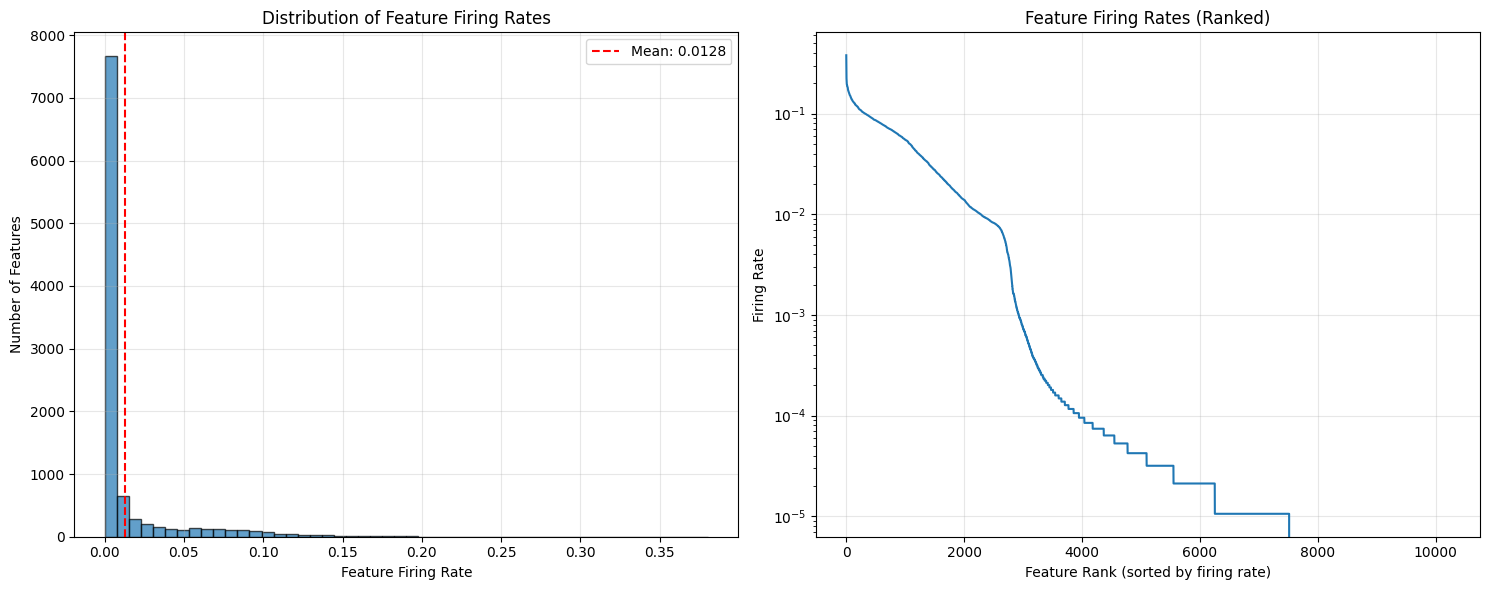

In [5]:
# Detailed analysis of SAE sparsity
def analyze_sae_sparsity():
    """Analyze overall SAE sparsity in detail"""
    
    print("=== SAE Sparsity Analysis ===")
    
    # Overall sparsity statistics
    all_sparse_activations = torch.cat(sparse_before_pooling, dim=0)  # [total_tokens, 2560]
    total_elements = all_sparse_activations.numel()
    nonzero_elements = torch.count_nonzero(all_sparse_activations).item()
    
    overall_sparsity = 1 - (nonzero_elements / total_elements)
    
    print(f"Total elements: {total_elements:,}")
    print(f"Non-zero elements: {nonzero_elements:,}")
    print(f"Overall sparsity: {overall_sparsity:.4f}")
    print(f"Active ratio: {1-overall_sparsity:.4f}")
    
    # Per-feature sparsity
    feature_sparsity = []
    for feature_idx in range(all_sparse_activations.shape[1]):
        feature_activations = all_sparse_activations[:, feature_idx]
        feature_nonzero = torch.count_nonzero(feature_activations).item()
        feature_sparsity_val = 1 - (feature_nonzero / len(feature_activations))
        feature_sparsity.append(feature_sparsity_val)
    
    feature_sparsity = np.array(feature_sparsity)
    
    print(f"\nFeature-wise sparsity statistics:")
    print(f"Mean feature sparsity: {feature_sparsity.mean():.4f}")
    print(f"Std feature sparsity: {feature_sparsity.std():.4f}")
    print(f"Min feature sparsity: {feature_sparsity.min():.4f}")
    print(f"Max feature sparsity: {feature_sparsity.max():.4f}")
    
    # Firing rate distribution
    firing_rates = 1 - feature_sparsity
    
    print(f"\nFeature firing rate distribution:")
    print(f"Features firing >50% of time: {np.sum(firing_rates > 0.5)}")
    print(f"Features firing >20% of time: {np.sum(firing_rates > 0.2)}")
    print(f"Features firing >10% of time: {np.sum(firing_rates > 0.1)}")
    print(f"Features firing >5% of time: {np.sum(firing_rates > 0.05)}")
    print(f"Features firing >1% of time: {np.sum(firing_rates > 0.01)}")
    print(f"Dead features (never firing): {np.sum(firing_rates == 0)}")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Firing rate histogram
    ax1.hist(firing_rates, bins=50, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Feature Firing Rate')
    ax1.set_ylabel('Number of Features')
    ax1.set_title('Distribution of Feature Firing Rates')
    ax1.axvline(firing_rates.mean(), color='red', linestyle='--', 
                label=f'Mean: {firing_rates.mean():.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Cumulative distribution
    sorted_rates = np.sort(firing_rates)[::-1]
    ax2.plot(range(len(sorted_rates)), sorted_rates)
    ax2.set_xlabel('Feature Rank (sorted by firing rate)')
    ax2.set_ylabel('Firing Rate')
    ax2.set_title('Feature Firing Rates (Ranked)')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return firing_rates, feature_sparsity

firing_rates, feature_sparsity = analyze_sae_sparsity()

## Linear Ridge Regression Using RidgeCV (sparse)

In [6]:
# Data splitting: same proteins as nbbench train.csv / test.csv (rows match vhh_thermo_seq.csv by seq)
thermo_dir = Path("../data/nbbench/thermo-seq")
df_vhh = pd.read_csv(thermo_dir / "vhh_thermo_seq.csv")
train_df = pd.read_csv(thermo_dir / "train.csv")
test_df = pd.read_csv(thermo_dir / "test.csv")

seq_to_idx = {seq: i for i, seq in enumerate(df_vhh["seq"])}
train_idx = np.array([seq_to_idx[s] for s in train_df["seq"]], dtype=int)
test_idx = np.array([seq_to_idx[s] for s in test_df["seq"]], dtype=int)

X_dense_train = X_dense[train_idx]
X_dense_test = X_dense[test_idx]
X_sparse_train = X_sparse[train_idx]
X_sparse_test = X_sparse[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
print(f"Train n={len(train_idx)}, Test n={len(test_idx)} (val split excluded)")

Train n=522, Test n=147 (val split excluded)


In [7]:
# Feature standardization
scaler_sparse = MaxAbsScaler()

X_sparse_train_scaled = scaler_sparse.fit_transform(X_sparse_train)
X_sparse_test_scaled = scaler_sparse.transform(X_sparse_test)

# Train with RidgeCV

alphas = np.logspace(-1, 4, 30)

ridgecv_sparse = RidgeCV(alphas=alphas, cv=10, scoring="neg_root_mean_squared_error")

ridgecv_sparse.fit(X_sparse_train_scaled, y_train)

print(f"Sparse: optimal α={ridgecv_sparse.alpha_}")

Sparse: optimal α=57.361525104486816


In [8]:
# Model performance evaluation
y_pred_sparse = ridgecv_sparse.predict(X_sparse_test_scaled)

def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    pearson = pearsonr(y_true, y_pred)[0]
    spearman = spearmanr(y_true, y_pred)[0]
    print(f"{name}: RMSE={rmse:.3f}, R²={r2:.3f}, MAE={mae:.3f}, Pearson={pearson:.3f}, Spearman={spearman:.3f}")
    return {'rmse': rmse, 'r2': r2, 'mae': mae, 'pearson': pearson, 'spearman': spearman}

# Performance evaluation
print("=== Performance evaluation ===")
sparse_metrics = evaluate_model(y_test, y_pred_sparse, "Sparse")

=== Performance evaluation ===
Sparse: RMSE=6.420, R²=0.626, MAE=4.808, Pearson=0.823, Spearman=0.787


## load head parameter of SFT model (dense)

In [9]:
from safetensors.torch import load_file
import torch
import torch.nn as nn
from pathlib import Path
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# load head parameter
path = '../supervised_finetuning/models/sft_esm2_8m_optuna'
model_root = Path(path)
head_path = model_root / 'head' / 'head_weights.safetensors'
if not head_path.exists():
    raise FileNotFoundError(f"Head weights not found: {head_path}")
head_weights = load_file(Path(head_path))
scaler_path = model_root / 'label_scaler.joblib'
if not scaler_path.exists():
    raise FileNotFoundError(f"Label scaler not found: {scaler_path}")
scaler = joblib.load(scaler_path)

print("loaded head parameter keys:", list(head_weights.keys()))
print("head parameter shapes:")
for key, value in head_weights.items():
    print(f"  {key}: {value.shape}")

def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    pearson, _ = pearsonr(y_true, y_pred)
    spearman, _ = spearmanr(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.3f}, R²={r2:.3f}, MAE={mae:.3f}, Pearson={pearson:.3f}, Spearman={spearman:.3f}")
    return {'rmse': rmse, 'r2': r2, 'mae': mae, 'pearson': pearson, 'spearman': spearman}

# build head model based on head parameter structure
class SimpleHead(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        return self.linear(x)

# estimate input dimension (from head parameter shape)
if 'weight' in head_weights and 'bias' in head_weights:
    input_dim = head_weights['weight'].shape[1]  # 320
    output_dim = head_weights['weight'].shape[0]  # 1
    head = SimpleHead(input_dim, output_dim)
    
    # set weight manually
    with torch.no_grad():
        head.linear.weight.data = head_weights['weight']
        head.linear.bias.data = head_weights['bias']
    
    head.eval()
    
    # convert X_sft to PyTorch tensor
    X_dense_test_tensor = torch.tensor(X_dense_test, dtype=torch.float32)
    
    # execute prediction
    with torch.no_grad():
        y_pred_dense_scaled = head(X_dense_test_tensor).squeeze().numpy()
    
    y_pred_dense = scaler.inverse_transform(y_pred_dense_scaled.reshape(-1, 1)).ravel()

    # performance evaluation
    print("=== performance comparison ===")
    sft_metrics = evaluate_model(y_test, y_pred_dense, "SFT")
    
else:
    print("The structure of the weight is different from the expected structure.")
    print("Available weights:", head_weights.keys())

loaded head parameter keys: ['bias', 'weight']
head parameter shapes:
  bias: torch.Size([1])
  weight: torch.Size([1, 320])
=== performance comparison ===
SFT: RMSE=6.750, R²=0.586, MAE=4.983, Pearson=0.814, Spearman=0.782


/home/taihei/.conda/envs/interplm/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MaxAbsScaler from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


/home/taihei/.conda/envs/interplm/lib/python3.11/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


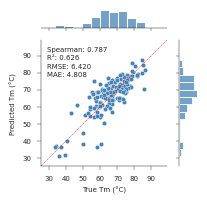

In [10]:
def create_joint_plot(tm_values, predictions, metrics,
                     title=None,
                     title_size=8,
                     figsize=(2, 2),      # Figure size
                     scatter_size=10,     # Scatter plot point size
                     tick_size=5,         # Axis tick font size
                     label_size=6,        # Axis label font size
                     stats_size=6,        # Statistics font size
                     linespacing=1.5):     # Statistics line spacing
    
    # Get evaluation metrics from metrics (dictionary format)
    rmse = metrics['rmse']
    r2 = metrics['r2']
    mae = metrics['mae']
    spearman = metrics['spearman']

    # Set plot style
    sns.set_style("whitegrid", {"grid.color": "0.9"})

    # Set border color (dark gray)
    BORDER_COLOR = 'black'

    # Set border width
    line_width = 0.3

    # Create joint plot
    jp = sns.jointplot(x=tm_values, y=predictions, 
                      kind="scatter", 
                      height=figsize[0],  # Set figure size
                      color="steelblue", 
                      edgecolor="w",
                      s=scatter_size)     # Set point size

    # Adjust bar plot position and size
    jp.ax_marg_x.set_position([0.05, 0.82, 0.7, 0.1])  # [left, bottom, width, height]
    jp.ax_marg_y.set_position([0.82, 0.05, 0.1, 0.7])  # [left, bottom, width, height]
    jp.ax_joint.set_position([0.05, 0.05, 0.7, 0.7]) 

    # Set plot range (fixed range 30-100)
    plot_min, plot_max = 25, 99
    jp.ax_joint.set_xlim(plot_min, plot_max)
    jp.ax_joint.set_ylim(plot_min, plot_max)

    # Set main plot (center) border
    for spine in jp.ax_joint.spines.values():
        if spine in [jp.ax_joint.spines['top'], jp.ax_joint.spines['right']]:
            spine.set_visible(False)
        else:  # bottom spine
            spine.set_visible(True)
            spine.set_color(BORDER_COLOR)
            spine.set_linewidth(line_width)

    # Set top histogram border
    for spine in jp.ax_marg_x.spines.values():
        if spine in [jp.ax_marg_x.spines['top'], jp.ax_marg_x.spines['left'], jp.ax_marg_x.spines['right']]:
            spine.set_visible(False)
        else:  # bottom spine
            spine.set_visible(True)
            spine.set_color(BORDER_COLOR)
            spine.set_linewidth(line_width)
    # Set top histogram grid
    jp.ax_marg_x.grid(False)
    jp.ax_marg_x.tick_params(axis='x', direction="out", bottom=True, length=2, width=line_width)

    # Set right histogram border
    for spine in jp.ax_marg_y.spines.values():
        if spine in [jp.ax_marg_y.spines['top'], jp.ax_marg_y.spines['bottom'], jp.ax_marg_y.spines['right']]:
            spine.set_visible(False)
        else:  # left spine
            spine.set_visible(True)
            spine.set_color(BORDER_COLOR)
            spine.set_linewidth(line_width)
    # Set right histogram grid
    jp.ax_marg_y.grid(False)
    jp.ax_marg_y.tick_params(axis='y', direction="out", left=True, length=2, width=line_width)
    
    # Set tick size
    jp.ax_joint.set_xticks([30, 40, 50, 60, 70, 80, 90])
    jp.ax_joint.tick_params(axis='both', direction="out", bottom=True, left=True, length=3, width=line_width, labelsize=tick_size)

    # Set grid to light gray
    jp.ax_joint.grid(False)

    # Add ideal prediction line (diagonal)
    jp.ax_joint.plot([plot_min, plot_max], [plot_min, plot_max], "r--", lw=0.3)

    # Set axis labels
    jp.set_axis_labels("True Tm (°C)", "Predicted Tm (°C)", fontsize=label_size)

    # Set title
    if title:
        jp.fig.suptitle(title, fontsize=title_size)

    # Display evaluation metrics on plot
    stats_text = (f"Spearman: {spearman:.3f}\n"
                 f"R²: {r2:.3f}\n"
                 f"RMSE: {rmse:.3f}\n"
                 f"MAE: {mae:.3f}")

    jp.ax_joint.text(0.05, 0.95, stats_text,
                     transform=jp.ax_joint.transAxes,
                     fontsize=stats_size,
                     verticalalignment="top",
                     linespacing=linespacing)
    
    return jp

def save_plot(jp, filename='evaluation_tm_supervised.png', dpi=350):
    """Function to save plot"""
    save_dir = 'figure'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    save_path = os.path.join(save_dir, filename)
    jp.savefig(save_path, dpi=dpi, format="png")

# Display scatter plots of each model's prediction results
jp_sparse = create_joint_plot(y_test,
                          y_pred_sparse,
                          sparse_metrics,
                          figsize=(1.8, 1.8),
                          scatter_size=10,
                          tick_size=5,
                          label_size=5,
                          stats_size=5)

save_plot(jp_sparse, filename='evaluation_tm_SparseSAE_SFT.png', dpi=350)
plt.show()


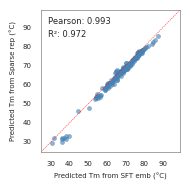

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
import os

def create_correlation_plot(y_pred_dense, y_pred_sparse, 
                           title=None,
                           figsize=(4, 4),
                           scatter_size=15,
                           tick_size=8,
                           label_size=10,
                           title_size=12,
                           stats_size=9,
                           linespacing=1.5):
    
    # Calculate correlation coefficient
    pearson_corr, pearson_p = pearsonr(y_pred_dense, y_pred_sparse)
    r2 = r2_score(y_pred_dense, y_pred_sparse)
    
    # Set plot style
    sns.set_style("whitegrid", {"grid.color": "0.9"})
    
    # Set border color and width
    BORDER_COLOR = '0.5'
    line_width = 0.5
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Create scatter plot
    ax.scatter(y_pred_dense, y_pred_sparse, 
               color="steelblue", 
               alpha=0.6, 
               s=scatter_size,
               linewidth=0.5)
    
    # Set plot range
    plot_min, plot_max = 25, 99
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    
    # Add ideal prediction line (diagonal)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], "r--", lw=0.3)
    
    # Set border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(BORDER_COLOR)
        spine.set_linewidth(line_width)
    
    # Set axis labels
    ax.set_xlabel("Predicted Tm from SFT emb (°C)", fontsize=label_size)
    ax.set_ylabel("Predicted Tm from Sparse rep (°C)", fontsize=label_size)

    # Set grid
    ax.grid(False)
    
    # Set title
    ax.set_title(title, fontsize=title_size, pad=15)
    
    # Display statistics on plot
    stats_text = (f"Pearson: {pearson_corr:.3f}\n"
                 f"R²: {r2:.3f}"
                 )

    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=stats_size,
            verticalalignment="top",
            linespacing=linespacing)
    
    # Set ticks
    ticks = np.arange(30, 100, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', width=line_width, labelsize=tick_size)
    
    plt.tight_layout()
    return fig, ax

# Visualize correlation
fig, ax = create_correlation_plot(y_pred_sparse, y_pred_dense,
                                 figsize=(2, 2),
                                 scatter_size=8,
                                 tick_size=5,
                                 label_size=5,
                                 stats_size=6,
                                 linespacing=1.5)

# Save
save_dir = 'figure'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

save_path = os.path.join(save_dir, 'original_vs_sparse_correlation_SFT.png')
plt.savefig(save_path, dpi=350, format="png", bbox_inches='tight')
plt.show()

## Sparse Feature Importance Analysis

In [12]:
# Get Ridge regression weights
sparse_weights = ridgecv_sparse.coef_
print(f"Sparse weights shape: {sparse_weights.shape}")

print(f"\nWeight statistics:")
print(f"  Positive weights: {np.sum(sparse_weights > 0)}")
print(f"  Negative weights: {np.sum(sparse_weights < 0)}")
print(f"  Zero weights: {np.sum(sparse_weights == 0)}")
print(f"  Max absolute weight: {np.max(np.abs(sparse_weights)):.6f}")
print(f"  Min absolute weight: {np.min(np.abs(sparse_weights)):.6f}")

# Find feature with maximum absolute value
max_weight_idx = np.argmax(np.abs(sparse_weights))
max_weight_value = sparse_weights[max_weight_idx]

print(f"Most important feature index: {max_weight_idx}")
print(f"Weight of most important feature: {max_weight_value:.6f}")

# Top 10 important features
top_indices = np.argsort(np.abs(sparse_weights))[-10:][::-1]
print(f"\nTop 10 important features:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. index={idx}, weight={sparse_weights[idx]:.6f}")


Sparse weights shape: (10240,)

Weight statistics:
  Positive weights: 3582
  Negative weights: 3657
  Zero weights: 3001
  Max absolute weight: 0.284535
  Min absolute weight: 0.000000
Most important feature index: 4597
Weight of most important feature: -0.284535

Top 10 important features:
  1. index=4597, weight=-0.284535
  2. index=1203, weight=-0.280825
  3. index=2367, weight=-0.275074
  4. index=7385, weight=-0.256168
  5. index=653, weight=-0.252819
  6. index=2139, weight=-0.237292
  7. index=3076, weight=-0.234686
  8. index=7744, weight=-0.218761
  9. index=6643, weight=0.215484
  10. index=7496, weight=0.211960


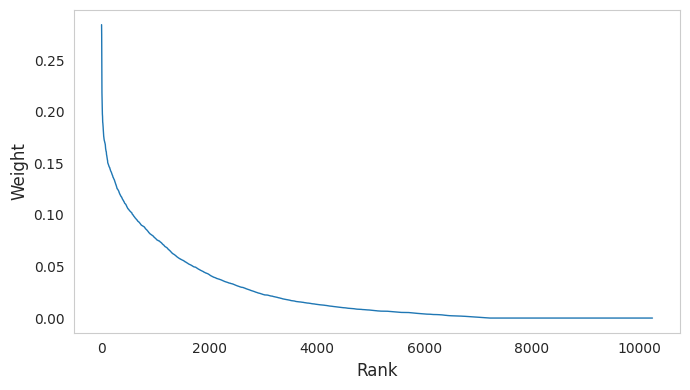

In [13]:
indices_sorted = np.argsort(-np.abs(sparse_weights))
sorted_weights = np.abs(sparse_weights[indices_sorted])
ranks = np.arange(len(sorted_weights))

# Plot(RidgeCV Regression Weights)
plt.figure(figsize=(7, 4))
plt.plot(ranks, sorted_weights, marker='', linestyle='-', linewidth=1)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Weight", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

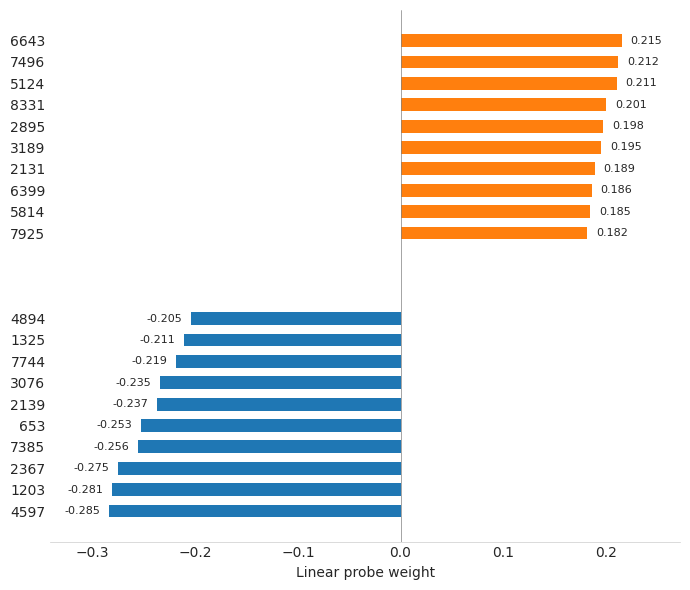

In [14]:
# ---- extract large weight features ----
# positive top10 (large to small)
pos_idx = np.argsort(sparse_weights)[-10:][::-1]
pos_w   = sparse_weights[pos_idx]

# negative top10 (small to large)
neg_idx_smallest = np.argsort(sparse_weights)[:10]
neg_idx = neg_idx_smallest[::-1]
neg_w   = sparse_weights[neg_idx]

# ---- display order (top: positive top10 → blank → bottom: negative top10)----
y_pos_pos = np.arange(0, 10)
y_pos_gap = np.array([10,11,12]) 
y_pos_neg = np.arange(13, 23)

# ---- draw ----
fig, ax = plt.subplots(figsize=(7, 6))

# bar (no frame・specify color・slightly thinner to ensure spacing)
ax.barh(y_pos_pos, pos_w, height=0.6, edgecolor="none", linewidth=0, color="tab:orange", zorder=2)
ax.barh(y_pos_neg, neg_w, height=0.6, edgecolor="none", linewidth=0, color="tab:blue",   zorder=2)

# display weight value on each bar
max_abs_weight = float(np.max(np.abs(np.concatenate([pos_w, neg_w])))) if len(pos_w) + len(neg_w) > 0 else 0.0
label_offset = max_abs_weight * 0.03 if max_abs_weight > 0 else 0.01

for y_val, weight in zip(y_pos_pos, pos_w):
    ax.text(weight + label_offset, y_val, f"{weight:.3f}", va="center", ha="left", fontsize=8)

for y_val, weight in zip(y_pos_neg, neg_w):
    ax.text(weight - label_offset, y_val, f"{weight:.3f}", va="center", ha="right", fontsize=8)

# expand x-axis range to prevent label overlap with y-axis label
if len(pos_w) + len(neg_w) > 0:
    all_weights = np.concatenate([pos_w, neg_w])
    min_weight = float(all_weights.min())
    max_weight = float(all_weights.max())
    margin = max(label_offset * 4, max_abs_weight * 0.2)
    ax.set_xlim(min_weight - margin, max_weight + margin)

# weight=0 line is black
ax.axvline(0, color="gray", linewidth=0.5, zorder=3)

# y-axis label is idx number (blank line is empty string)
ax.set_yticks(np.concatenate([y_pos_pos, y_pos_gap, y_pos_neg]))
ax.set_yticklabels([str(i) for i in pos_idx] + [""]*len(y_pos_gap) + [str(i) for i in neg_idx])

# spine setting: only y-axis is visible (others are hidden)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_linewidth(0.5)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# tick lines are hidden (adjust if necessary)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.grid(False)

# invert y-axis
ax.invert_yaxis()

ax.set_xlabel("Linear probe weight")

plt.tight_layout()
plt.show()

## Feature Activation Global Analysis by Aho aligned position

In [16]:
# Function to build ungapped to AHO mapping (from Cell 28)
def build_ungapped_to_aho_map(seq_aho: str):
    """
    Create a map associating ungapped sequence indices with AHO positions
    from a gapped AHO-aligned sequence.
    """
    mapping = []
    for i, ch in enumerate(seq_aho):
        if ch != '-':
            mapping.append(i + 1)  # AHo positions are 1-based
    return mapping

# Initialize arrays
num_features = len(sparse_weights)  # 2560
num_proteins = len(sparse_before_pooling)  # 567
aho_len = 149

print(f"Creating activation array for all features...")
print(f"Shape: ({num_features}, {num_proteins}, {aho_len})")
print(f"Memory estimate: {num_features * num_proteins * aho_len * 4 / 1024**3:.2f} GB (float32)")

# Create array to store all feature activations aligned to AHO positions
# Shape: (num_features, num_proteins, aho_len)
all_features_aho_activations = np.zeros((num_features, num_proteins, aho_len), dtype=np.float32)

print("\nProcessing features...")
for feature_idx in range(num_features):
    if (feature_idx + 1) % 100 == 0:
        print(f"  Processed {feature_idx + 1}/{num_features} features...")
    
    # Get activation pattern of the feature in each protein
    for protein_id in range(num_proteins):
        # Get ungapped activations for this feature
        protein_tensor = sparse_before_pooling[protein_id]  # [seq_len, 2560]
        feature_activations = protein_tensor[:, feature_idx].numpy()  # [seq_len]
        
        # Get AHO alignment mapping
        aho_gapped_sequence = df.loc[protein_id]['sequence_aho']
        ungapped_to_aho = build_ungapped_to_aho_map(aho_gapped_sequence)
        
        # Map activations to AHO positions
        L = min(len(feature_activations), len(ungapped_to_aho))
        for u_idx in range(L):
            aho_pos = ungapped_to_aho[u_idx] - 1  # Convert to 0-based
            if 0 <= aho_pos < aho_len:
                all_features_aho_activations[feature_idx, protein_id, aho_pos] = feature_activations[u_idx]

print(f"\nCompleted processing all {num_features} features!")

# Save the array
output_dir = './feature_activation_data'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'sparse_all_features_aho_activations_sft.npy')
np.save(output_path, all_features_aho_activations)
print(f"\nSaved activation array to: {output_path}")
print(f"Array shape: {all_features_aho_activations.shape}")
print(f"Array dtype: {all_features_aho_activations.dtype}")

Creating activation array for all features...
Shape: (10240, 764, 149)
Memory estimate: 4.34 GB (float32)

Processing features...
  Processed 100/10240 features...
  Processed 200/10240 features...
  Processed 300/10240 features...
  Processed 400/10240 features...
  Processed 500/10240 features...
  Processed 600/10240 features...
  Processed 700/10240 features...
  Processed 800/10240 features...
  Processed 900/10240 features...
  Processed 1000/10240 features...
  Processed 1100/10240 features...
  Processed 1200/10240 features...
  Processed 1300/10240 features...
  Processed 1400/10240 features...
  Processed 1500/10240 features...
  Processed 1600/10240 features...
  Processed 1700/10240 features...
  Processed 1800/10240 features...
  Processed 1900/10240 features...
  Processed 2000/10240 features...
  Processed 2100/10240 features...
  Processed 2200/10240 features...
  Processed 2300/10240 features...
  Processed 2400/10240 features...
  Processed 2500/10240 features...
  Pr

### Feature Statistics Calculation

In [15]:
data_path = './feature_activation_data/sparse_all_features_aho_activations_sft.npy'
all_features_aho_activations = np.load(data_path)

# Initialize arrays
num_features = len(sparse_weights) 
num_proteins = len(sparse_before_pooling)
aho_len = 149

# Calculate statistics for each feature
print("Calculating feature statistics...")

feature_stats = []

for feature_idx in range(num_features):
    # Get activations for this feature across all proteins and AHO positions
    # Shape: (num_proteins, aho_len)
    feature_activations = all_features_aho_activations[feature_idx, :, :]
    
    # Calculate statistics per AHO position
    mean_per_position = np.mean(feature_activations, axis=0)  # (aho_len,)
    max_per_position = np.max(feature_activations, axis=0)  # (aho_len,)
    nonzero_count_per_position = np.count_nonzero(feature_activations, axis=0)  # (aho_len,)
    
    # Calculate overall statistics
    total_nonzero = np.count_nonzero(feature_activations)
    total_elements = feature_activations.size
    sparsity = 1 - (total_nonzero / total_elements) if total_elements > 0 else 1.0
    
    # Calculate activation pattern: local vs global
    # Local: activation concentrated in specific positions
    # Global: activation spread across many positions
    nonzero_positions = np.count_nonzero(mean_per_position > 0)
    activation_spread_ratio = nonzero_positions / aho_len
    
    # Calculate coefficient of variation to measure localization
    # Higher CV = more localized, Lower CV = more uniform
    mean_activation = np.mean(feature_activations[feature_activations > 0]) if total_nonzero > 0 else 0.0
    std_activation = np.std(feature_activations[feature_activations > 0]) if total_nonzero > 0 else 0.0
    cv = std_activation / mean_activation if mean_activation > 0 else 0.0
    
    feature_stats.append({
        'feature_idx': feature_idx,
        'weight': sparse_weights[feature_idx],
        'abs_weight': np.abs(sparse_weights[feature_idx]),
        'weight_rank': 0,  # Will be filled later
        'mean_per_position': mean_per_position,
        'max_per_position': max_per_position,
        'nonzero_count_per_position': nonzero_count_per_position,
        'total_nonzero': total_nonzero,
        'sparsity': sparsity,
        'activation_spread_ratio': activation_spread_ratio,
        'cv': cv,
        'mean_activation': mean_activation,
        'max_activation': np.max(feature_activations),
    })
    
    if (feature_idx + 1) % 500 == 0:
        print(f"  Processed {feature_idx + 1}/{num_features} features...")

print(f"\nCompleted calculating statistics for all {num_features} features!")

# Sort by absolute weight and assign ranks
sorted_indices = np.argsort(-np.abs(sparse_weights))  # Descending order
for rank, feature_idx in enumerate(sorted_indices):
    feature_stats[feature_idx]['weight_rank'] = rank + 1

print(f"Assigned weight ranks to all features.")

Calculating feature statistics...
  Processed 500/10240 features...
  Processed 1000/10240 features...
  Processed 1500/10240 features...
  Processed 2000/10240 features...
  Processed 2500/10240 features...
  Processed 3000/10240 features...
  Processed 3500/10240 features...
  Processed 4000/10240 features...
  Processed 4500/10240 features...
  Processed 5000/10240 features...
  Processed 5500/10240 features...
  Processed 6000/10240 features...
  Processed 6500/10240 features...
  Processed 7000/10240 features...
  Processed 7500/10240 features...
  Processed 8000/10240 features...
  Processed 8500/10240 features...
  Processed 9000/10240 features...
  Processed 9500/10240 features...
  Processed 10000/10240 features...

Completed calculating statistics for all 10240 features!
Assigned weight ranks to all features.


In [17]:
# Convert to DataFrame for easier analysis
stats_data = []
for stat in feature_stats:
    stats_data.append({
        'feature_idx': stat['feature_idx'],
        'weight': stat['weight'],
        'abs_weight': stat['abs_weight'],
        'weight_rank': stat['weight_rank'],
        'sparsity': stat['sparsity'],
        'activation_spread_ratio': stat['activation_spread_ratio'],
        'cv': stat['cv'],
        'mean_activation': stat['mean_activation'],
        'max_activation': stat['max_activation'],
        'total_nonzero': stat['total_nonzero'],
    })

df_feature_stats = pd.DataFrame(stats_data)
df_feature_stats = df_feature_stats.sort_values('abs_weight', ascending=False)

# Save statistics
output_dir = './feature_activation_data'
stats_output_path = os.path.join(output_dir, 'feature_statistics.csv')
df_feature_stats.to_csv(stats_output_path, index=False)
print(f"Saved feature statistics to: {stats_output_path}")

# Display summary statistics
print("\n=== Feature Statistics Summary ===")
print(f"Total features: {len(df_feature_stats)}")
print(f"\nWeight statistics:")
print(f"  Mean absolute weight: {df_feature_stats['abs_weight'].mean():.6f}")
print(f"  Median absolute weight: {df_feature_stats['abs_weight'].median():.6f}")
print(f"  Std absolute weight: {df_feature_stats['abs_weight'].std():.6f}")

print(f"\nActivation pattern statistics:")
print(f"  Mean sparsity: {df_feature_stats['sparsity'].mean():.4f}")
print(f"  Mean activation spread ratio: {df_feature_stats['activation_spread_ratio'].mean():.4f}")
print(f"  Features with spread ratio > 0.8 (global): {np.sum(df_feature_stats['activation_spread_ratio'] > 0.8)}")
print(f"  Features with spread ratio < 0.2 (local): {np.sum(df_feature_stats['activation_spread_ratio'] < 0.2)}")

print(f"\nTop 10 features by absolute weight:")
print(df_feature_stats[['feature_idx', 'weight', 'abs_weight', 'weight_rank', 
                        'sparsity', 'activation_spread_ratio']].head(10).to_string(index=False))

Saved feature statistics to: ./feature_activation_data/feature_statistics.csv

=== Feature Statistics Summary ===
Total features: 10240

Weight statistics:
  Mean absolute weight: 0.023428
  Median absolute weight: 0.007021
  Std absolute weight: 0.036080

Activation pattern statistics:
  Mean sparsity: 0.9895
  Mean activation spread ratio: 0.1620
  Features with spread ratio > 0.8 (global): 658
  Features with spread ratio < 0.2 (local): 7581

Top 10 features by absolute weight:
 feature_idx    weight  abs_weight  weight_rank  sparsity  activation_spread_ratio
        4597 -0.284535    0.284535            1  0.910081                 0.879195
        1203 -0.280825    0.280825            2  0.971564                 0.664430
        2367 -0.275074    0.275074            3  0.963456                 0.711409
        7385 -0.256168    0.256168            4  0.972619                 0.570470
         653 -0.252819    0.252819            5  0.955243                 0.785235
        2139 -0.

### Visualization of Feature Statistics

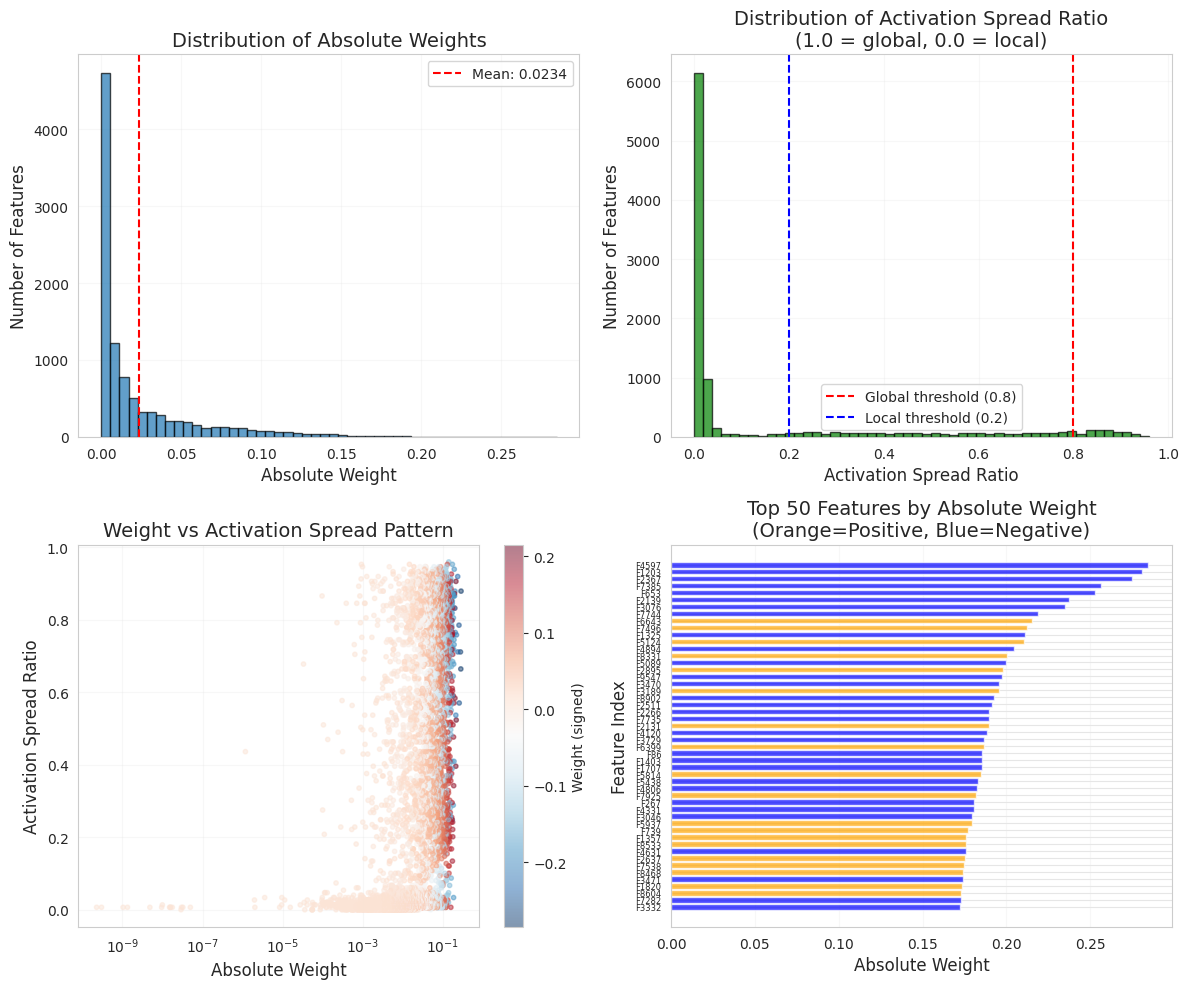

In [18]:
# Visualize feature statistics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Weight distribution
ax = axes[0, 0]
ax.hist(df_feature_stats['abs_weight'], bins=50, alpha=0.7, edgecolor='black')
ax.set_xlabel('Absolute Weight', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Distribution of Absolute Weights', fontsize=14)
ax.axvline(df_feature_stats['abs_weight'].mean(), color='red', linestyle='--', 
           label=f'Mean: {df_feature_stats["abs_weight"].mean():.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Activation spread ratio distribution
ax = axes[0, 1]
ax.hist(df_feature_stats['activation_spread_ratio'], bins=50, alpha=0.7, edgecolor='black', color='green')
ax.set_xlabel('Activation Spread Ratio', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Distribution of Activation Spread Ratio\n(1.0 = global, 0.0 = local)', fontsize=14)
ax.axvline(0.8, color='red', linestyle='--', label='Global threshold (0.8)')
ax.axvline(0.2, color='blue', linestyle='--', label='Local threshold (0.2)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Weight vs Activation spread ratio
ax = axes[1, 0]
scatter = ax.scatter(df_feature_stats['abs_weight'], df_feature_stats['activation_spread_ratio'], 
                     alpha=0.5, s=10, c=df_feature_stats['weight'], cmap='RdBu_r')
ax.set_xlabel('Absolute Weight', fontsize=12)
ax.set_ylabel('Activation Spread Ratio', fontsize=12)
ax.set_title('Weight vs Activation Spread Pattern', fontsize=14)
ax.set_xscale('log')
plt.colorbar(scatter, ax=ax, label='Weight (signed)')
ax.grid(True, alpha=0.3)

# 4. Top features by weight (positive vs negative)
ax = axes[1, 1]
top_n = 50
top_features = df_feature_stats.head(top_n)
colors = ['orange' if w > 0 else 'blue' for w in top_features['weight']]
ax.barh(range(len(top_features)), top_features['abs_weight'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f"F{idx}" for idx in top_features['feature_idx']], fontsize=6)
ax.set_xlabel('Absolute Weight', fontsize=12)
ax.set_ylabel('Feature Index', fontsize=12)
ax.set_title(f'Top {top_n} Features by Absolute Weight\n(Orange=Positive, Blue=Negative)', fontsize=14)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()

plt.show()


### Positive vs Negative Weight Feature Activation Patterns

In [19]:
# Separate features by weight sign
positive_weight_features = [i for i, w in enumerate(sparse_weights) if w > 0]
negative_weight_features = [i for i, w in enumerate(sparse_weights) if w < 0]

print(f"Positive weight features: {len(positive_weight_features)}")
print(f"Negative weight features: {len(negative_weight_features)}")

# Calculate average activation per AHO position for each group
# Weighted by absolute weight to emphasize important features
positive_activations = all_features_aho_activations[positive_weight_features, :, :]  # (n_pos, num_proteins, aho_len)
negative_activations = all_features_aho_activations[negative_weight_features, :, :]  # (n_neg, num_proteins, aho_len)

positive_weights = sparse_weights[positive_weight_features]
negative_weights = sparse_weights[negative_weight_features]

# Calculate weighted average activation per position
# focus on features with large absolute weights
weight_magnitude_threshold = 0.05  # Adjust as needed
print(f"\nApplying absolute weight threshold >= {weight_magnitude_threshold:.3f} to select strong features")

positive_mask_threshold = positive_weights >= weight_magnitude_threshold
negative_mask_threshold = np.abs(negative_weights) >= weight_magnitude_threshold

positive_strong_activations = positive_activations[positive_mask_threshold]
positive_strong_weights = positive_weights[positive_mask_threshold]
negative_strong_activations = negative_activations[negative_mask_threshold]
negative_strong_weights = negative_weights[negative_mask_threshold]

print(f"  Positive features above threshold: {len(positive_strong_weights)}")
print(f"  Negative features above threshold: {len(negative_strong_weights)}")

positive_weighted_mean_strong = np.zeros(aho_len)
if positive_strong_activations.size > 0:
    pos_strong_abs_sum = np.sum(np.abs(positive_strong_weights))
    for i in range(positive_strong_activations.shape[0]):
        mean_activation = np.mean(positive_strong_activations[i, :, :], axis=0)
        positive_weighted_mean_strong += mean_activation * np.abs(positive_strong_weights[i])
    positive_weighted_mean_strong /= pos_strong_abs_sum if pos_strong_abs_sum > 0 else 1.0

negative_weighted_mean_strong = np.zeros(aho_len)
if negative_strong_activations.size > 0:
    neg_strong_abs_sum = np.sum(np.abs(negative_strong_weights))
    for i in range(negative_strong_activations.shape[0]):
        mean_activation = np.mean(negative_strong_activations[i, :, :], axis=0)
        negative_weighted_mean_strong += mean_activation * np.abs(negative_strong_weights[i])
    negative_weighted_mean_strong /= neg_strong_abs_sum if neg_strong_abs_sum > 0 else 1.0

positive_simple_mean_strong = (
    np.mean(positive_strong_activations, axis=(0, 1)) if positive_strong_activations.size > 0 else np.zeros(aho_len)
)
negative_simple_mean_strong = (
    np.mean(negative_strong_activations, axis=(0, 1)) if negative_strong_activations.size > 0 else np.zeros(aho_len)
)

if positive_strong_activations.size > 0:
    print(
        f"    Positive (filtered) - weighted range: [{positive_weighted_mean_strong.min():.6f}, {positive_weighted_mean_strong.max():.6f}]"
    )
else:
    print("    Positive (filtered) - no features above threshold")

if negative_strong_activations.size > 0:
    print(
        f"    Negative (filtered) - weighted range: [{negative_weighted_mean_strong.min():.6f}, {negative_weighted_mean_strong.max():.6f}]"
    )
else:
    print("    Negative (filtered) - no features above threshold")


Positive weight features: 3582
Negative weight features: 3657

Applying absolute weight threshold >= 0.050 to select strong features
  Positive features above threshold: 877
  Negative features above threshold: 827
    Positive (filtered) - weighted range: [0.000000, 0.005745]
    Negative (filtered) - weighted range: [0.000000, 0.006535]


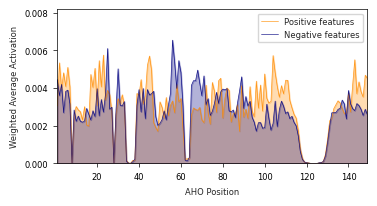

In [32]:
# Visualize positive vs negative weight feature activation patterns
aho_len = 149
aho_positions = np.arange(1, aho_len + 1)  # 1-based positions

tm_dataset_path = "../data/nbbench/thermo-seq/vhh_thermo_seq.csv"

tm_dataset = pd.read_csv(tm_dataset_path, usecols=["sequence_aho"])
nbthermo_sequences = tm_dataset["sequence_aho"].dropna().tolist()

if not nbthermo_sequences:
    raise ValueError("No NbThermo sequences found in vhh_tm_dataset.csv.")

valid_sequences = []
invalid_length_counter = {}
for seq in nbthermo_sequences:
    seq = seq.strip()
    seq_len = len(seq)
    if seq_len == aho_len:
        valid_sequences.append(seq)
    else:
        invalid_length_counter[seq_len] = invalid_length_counter.get(seq_len, 0) + 1

if invalid_length_counter:
    print(
        "Warning: Ignoring NbThermo sequences with unexpected AHO length:",
        invalid_length_counter,
    )

if not valid_sequences:
    raise ValueError(
        "No NbThermo sequences with expected AHO alignment length found after filtering."
    )

nbthermo_non_gap_fraction = np.vstack([
    np.array([residue != '-' for residue in seq], dtype=np.float32)
    for seq in valid_sequences
]).mean(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(4, 2))

BORDER_COLOR = '0.5'
line_width = 0.5


# 3. Weighted average using only strong-weight features
ax.plot(aho_positions, positive_weighted_mean_strong, label='Positive features', 
        color='darkorange', linewidth=0.5, alpha=0.85)
ax.plot(aho_positions, negative_weighted_mean_strong, label='Negative features', 
        color='navy', linewidth=0.5, alpha=0.85)
ax.fill_between(aho_positions, positive_weighted_mean_strong, alpha=0.3, color='darkorange')
ax.fill_between(aho_positions, negative_weighted_mean_strong, alpha=0.3, color='navy')
ax.set_xlabel('AHO Position', fontsize=6)
ax.set_ylabel('Weighted Average Activation', fontsize=6)
ax.legend(fontsize=6)
ax.grid(False)
ax.set_xlim(1, aho_len)
ax.set_ylim(0, max(positive_weighted_mean_strong.max(), negative_weighted_mean_strong.max())*1.25)
ax.tick_params(
    axis="both", which="both",
    direction="out",
    bottom=True, top=False,
    left=True, right=False,
    length=3.0, width=line_width,
    color="black",       # 目盛線の色
    labelcolor="black",
    labelsize=6
)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.002))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))  # 0.002なら小数3桁が見やすい
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(line_width)

save_dir = 'figure'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

save_path = os.path.join(save_dir, 'SAE_features_global_analysis_sft.png')
plt.savefig(save_path, dpi=350, format="png", bbox_inches='tight')
plt.show()


df_positive = pd.DataFrame({
    "aho_position": aho_positions,
    "positive_weighted_mean_strong": positive_weighted_mean_strong
})

df_negative = pd.DataFrame({
    "aho_position": aho_positions,
    "negative_weighted_mean_strong": negative_weighted_mean_strong
})


output_dir = './feature_activation_data'
df_positive.to_csv(os.path.join(output_dir, 'sft_features_global_analysis_positive.csv'), index=False)
df_negative.to_csv(os.path.join(output_dir, 'sft_features_global_analysis_negative.csv'), index=False)

## 後ほど削除

In [34]:
# Separate features by weight sign
positive_weight_features = [i for i, w in enumerate(sparse_weights) if w > 0]
negative_weight_features = [i for i, w in enumerate(sparse_weights) if w < 0]

print(f"Positive weight features: {len(positive_weight_features)}")
print(f"Negative weight features: {len(negative_weight_features)}")

# Calculate average activation per AHO position for each group
# Weighted by absolute weight to emphasize important features
positive_activations = all_features_aho_activations[positive_weight_features, :, :]  # (n_pos, num_proteins, aho_len)
negative_activations = all_features_aho_activations[negative_weight_features, :, :]  # (n_neg, num_proteins, aho_len)

positive_weights = sparse_weights[positive_weight_features]
negative_weights = sparse_weights[negative_weight_features]

# Calculate weighted average activation per position
# Shape: (aho_len,)
positive_weighted_mean = np.zeros(aho_len)
positive_abs_weights_sum = np.sum(np.abs(positive_weights))
for i, feature_idx in enumerate(positive_weight_features):
    weight = positive_weights[i]
    abs_weight = np.abs(weight)
    # Average across proteins, then weight by absolute weight
    mean_activation = np.mean(positive_activations[i, :, :], axis=0)  # (aho_len,)
    positive_weighted_mean += mean_activation * abs_weight
positive_weighted_mean /= positive_abs_weights_sum if positive_abs_weights_sum > 0 else 1.0

negative_weighted_mean = np.zeros(aho_len)
negative_abs_weights_sum = np.sum(np.abs(negative_weights))
for i, feature_idx in enumerate(negative_weight_features):
    weight = negative_weights[i]
    abs_weight = np.abs(weight)
    # Average across proteins, then weight by absolute weight
    mean_activation = np.mean(negative_activations[i, :, :], axis=0)  # (aho_len,)
    negative_weighted_mean += mean_activation * abs_weight
negative_weighted_mean /= negative_abs_weights_sum if negative_abs_weights_sum > 0 else 1.0

# Also calculate simple mean (not weighted)
positive_simple_mean = np.mean(positive_activations, axis=(0, 1))  # Average over features and proteins
negative_simple_mean = np.mean(negative_activations, axis=(0, 1))  # Average over features and proteins

print(f"\nPositive weight features - weighted average activation range: [{positive_weighted_mean.min():.6f}, {positive_weighted_mean.max():.6f}]")
print(f"Negative weight features - weighted average activation range: [{negative_weighted_mean.min():.6f}, {negative_weighted_mean.max():.6f}]")

# --- Additional analysis: focus on features with large absolute weights ---
weight_magnitude_threshold = 0.05  # Adjust as needed
print(f"\nApplying absolute weight threshold >= {weight_magnitude_threshold:.3f} to select strong features")

positive_mask_threshold = positive_weights >= weight_magnitude_threshold
negative_mask_threshold = np.abs(negative_weights) >= weight_magnitude_threshold

positive_strong_activations = positive_activations[positive_mask_threshold]
positive_strong_weights = positive_weights[positive_mask_threshold]
negative_strong_activations = negative_activations[negative_mask_threshold]
negative_strong_weights = negative_weights[negative_mask_threshold]

print(f"  Positive features above threshold: {len(positive_strong_weights)}")
print(f"  Negative features above threshold: {len(negative_strong_weights)}")

positive_weighted_mean_strong = np.zeros(aho_len)
if positive_strong_activations.size > 0:
    pos_strong_abs_sum = np.sum(np.abs(positive_strong_weights))
    for i in range(positive_strong_activations.shape[0]):
        mean_activation = np.mean(positive_strong_activations[i, :, :], axis=0)
        positive_weighted_mean_strong += mean_activation * np.abs(positive_strong_weights[i])
    positive_weighted_mean_strong /= pos_strong_abs_sum if pos_strong_abs_sum > 0 else 1.0

negative_weighted_mean_strong = np.zeros(aho_len)
if negative_strong_activations.size > 0:
    neg_strong_abs_sum = np.sum(np.abs(negative_strong_weights))
    for i in range(negative_strong_activations.shape[0]):
        mean_activation = np.mean(negative_strong_activations[i, :, :], axis=0)
        negative_weighted_mean_strong += mean_activation * np.abs(negative_strong_weights[i])
    negative_weighted_mean_strong /= neg_strong_abs_sum if neg_strong_abs_sum > 0 else 1.0

positive_simple_mean_strong = (
    np.mean(positive_strong_activations, axis=(0, 1)) if positive_strong_activations.size > 0 else np.zeros(aho_len)
)
negative_simple_mean_strong = (
    np.mean(negative_strong_activations, axis=(0, 1)) if negative_strong_activations.size > 0 else np.zeros(aho_len)
)

if positive_strong_activations.size > 0:
    print(
        f"    Positive (filtered) - weighted range: [{positive_weighted_mean_strong.min():.6f}, {positive_weighted_mean_strong.max():.6f}]"
    )
else:
    print("    Positive (filtered) - no features above threshold")

if negative_strong_activations.size > 0:
    print(
        f"    Negative (filtered) - weighted range: [{negative_weighted_mean_strong.min():.6f}, {negative_weighted_mean_strong.max():.6f}]"
    )
else:
    print("    Negative (filtered) - no features above threshold")


Positive weight features: 3582
Negative weight features: 3657

Positive weight features - weighted average activation range: [0.000000, 0.004408]
Negative weight features - weighted average activation range: [0.000000, 0.004540]

Applying absolute weight threshold >= 0.050 to select strong features
  Positive features above threshold: 877
  Negative features above threshold: 827
    Positive (filtered) - weighted range: [0.000000, 0.005745]
    Negative (filtered) - weighted range: [0.000000, 0.006535]


Saved visualization to: ./feature_activation_data/positive_negative_activation_patterns.png


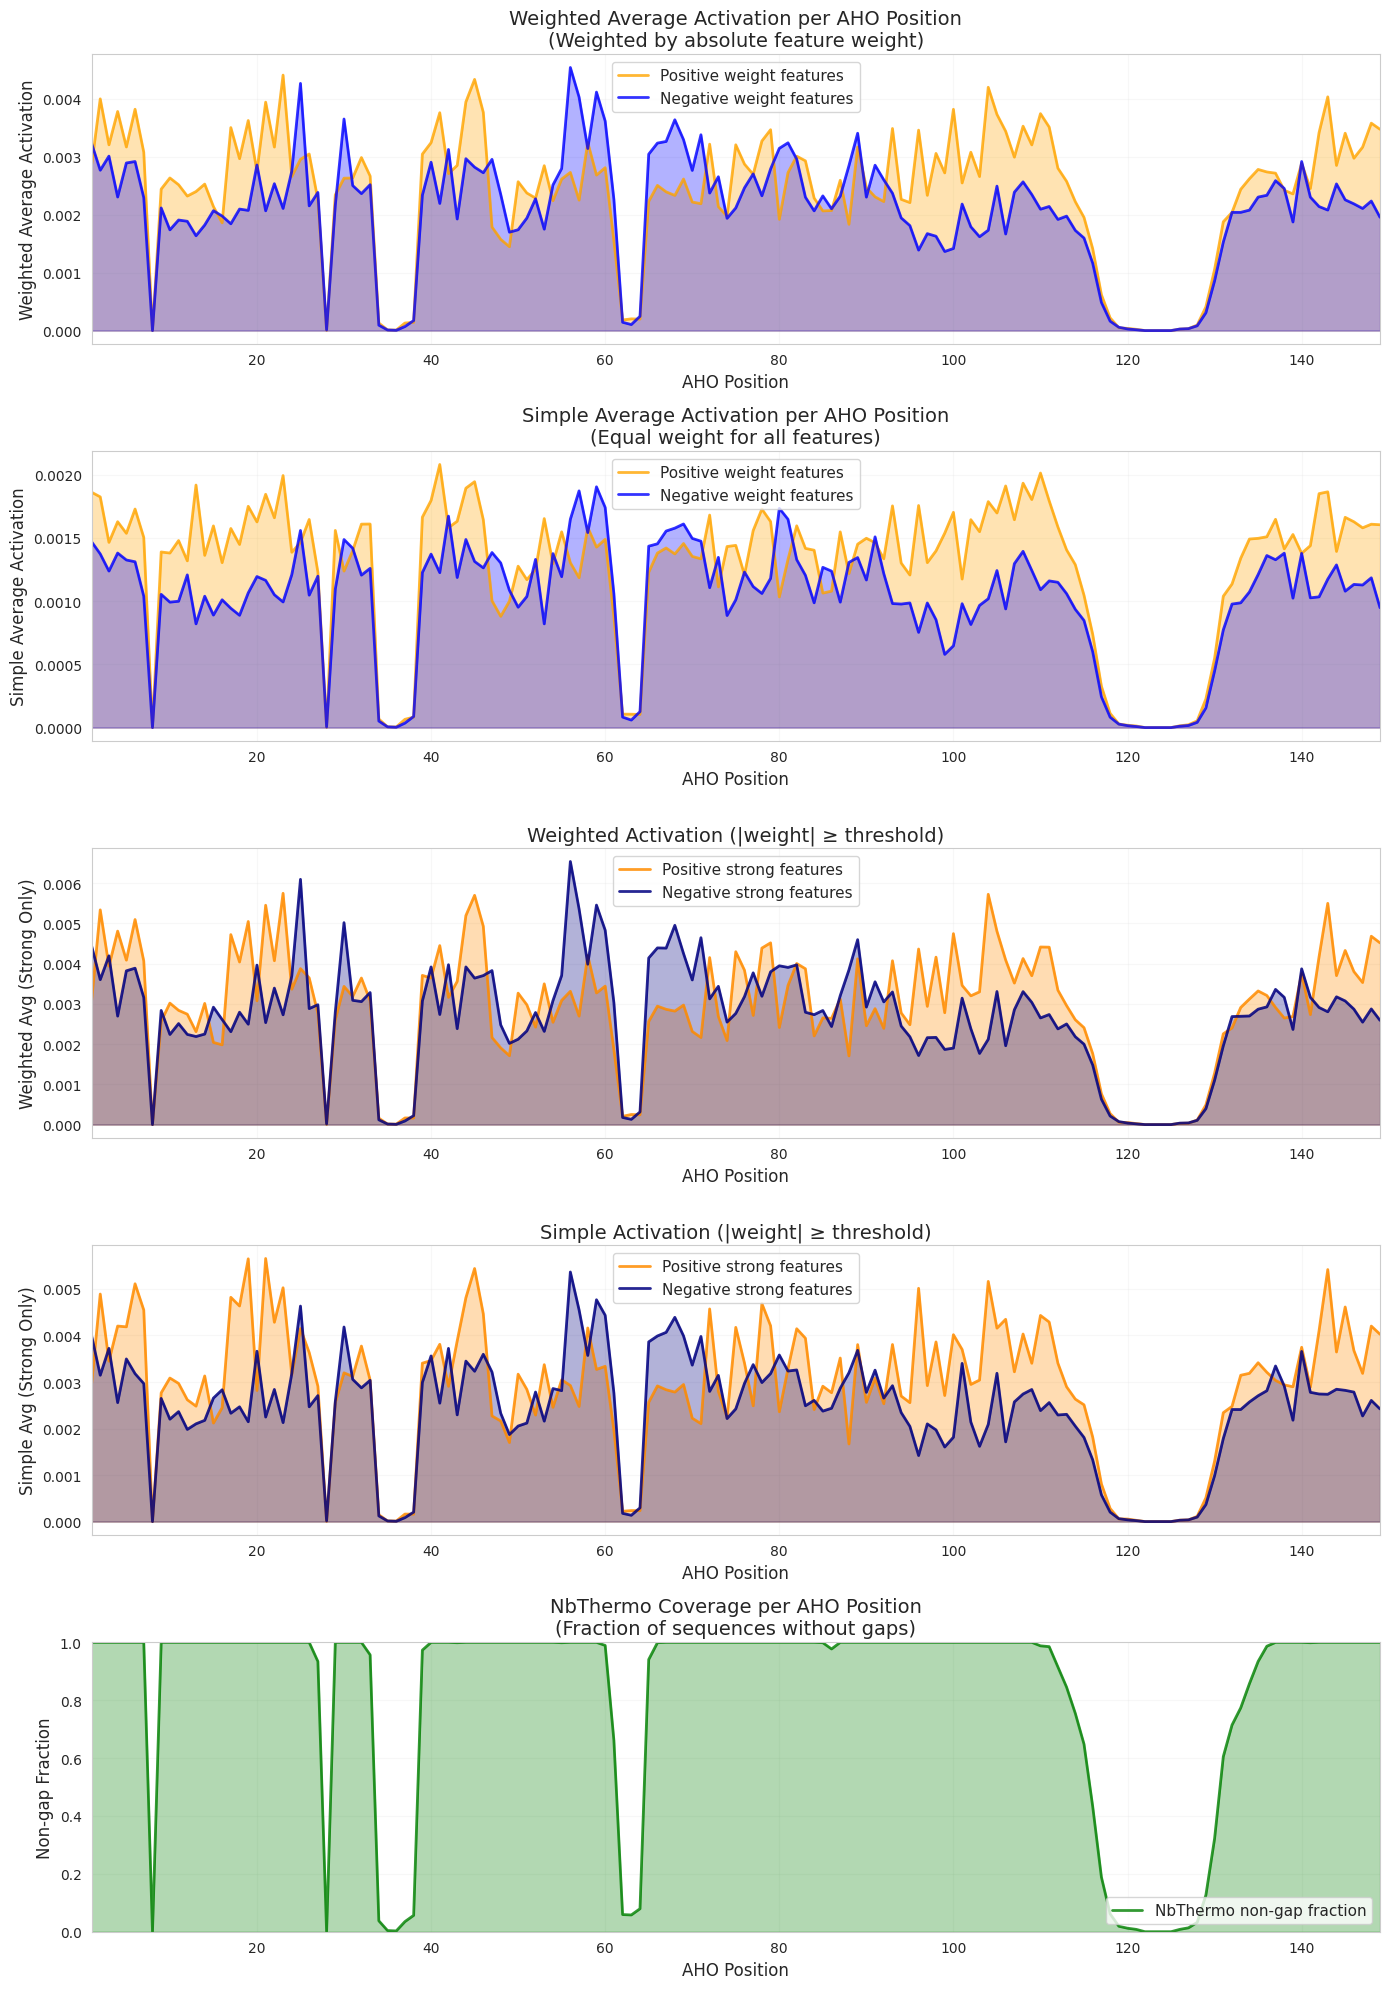

In [35]:
# Visualize positive vs negative weight feature activation patterns
aho_len = 149
aho_positions = np.arange(1, aho_len + 1)  # 1-based positions

tm_dataset_path = "../data/nbbench/thermo-seq/vhh_thermo_seq.csv"

tm_dataset = pd.read_csv(tm_dataset_path, usecols=["sequence_aho"])
nbthermo_sequences = tm_dataset["sequence_aho"].dropna().tolist()

if not nbthermo_sequences:
    raise ValueError("No NbThermo sequences found in vhh_tm_dataset.csv.")

valid_sequences = []
invalid_length_counter = {}
for seq in nbthermo_sequences:
    seq = seq.strip()
    seq_len = len(seq)
    if seq_len == aho_len:
        valid_sequences.append(seq)
    else:
        invalid_length_counter[seq_len] = invalid_length_counter.get(seq_len, 0) + 1

if invalid_length_counter:
    print(
        "Warning: Ignoring NbThermo sequences with unexpected AHO length:",
        invalid_length_counter,
    )

if not valid_sequences:
    raise ValueError(
        "No NbThermo sequences with expected AHO alignment length found after filtering."
    )

nbthermo_non_gap_fraction = np.vstack([
    np.array([residue != '-' for residue in seq], dtype=np.float32)
    for seq in valid_sequences
]).mean(axis=0)

fig, axes = plt.subplots(5, 1, figsize=(14, 20))
axes = axes.flatten()

# 1. Weighted average activation per AHO position
ax = axes[0]
ax.plot(aho_positions, positive_weighted_mean, label='Positive weight features', 
        color='orange', linewidth=2, alpha=0.8)
ax.plot(aho_positions, negative_weighted_mean, label='Negative weight features', 
        color='blue', linewidth=2, alpha=0.8)
ax.fill_between(aho_positions, positive_weighted_mean, alpha=0.3, color='orange')
ax.fill_between(aho_positions, negative_weighted_mean, alpha=0.3, color='blue')
ax.set_xlabel('AHO Position', fontsize=12)
ax.set_ylabel('Weighted Average Activation', fontsize=12)
ax.set_title('Weighted Average Activation per AHO Position\n(Weighted by absolute feature weight)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, aho_len)

# 2. Simple average activation per AHO position
ax = axes[1]
ax.plot(aho_positions, positive_simple_mean, label='Positive weight features', 
        color='orange', linewidth=2, alpha=0.8)
ax.plot(aho_positions, negative_simple_mean, label='Negative weight features', 
        color='blue', linewidth=2, alpha=0.8)
ax.fill_between(aho_positions, positive_simple_mean, alpha=0.3, color='orange')
ax.fill_between(aho_positions, negative_simple_mean, alpha=0.3, color='blue')
ax.set_xlabel('AHO Position', fontsize=12)
ax.set_ylabel('Simple Average Activation', fontsize=12)
ax.set_title('Simple Average Activation per AHO Position\n(Equal weight for all features)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, aho_len)

# 3. Weighted average using only strong-weight features
ax = axes[2]
ax.plot(aho_positions, positive_weighted_mean_strong, label='Positive strong features', 
        color='darkorange', linewidth=2, alpha=0.85)
ax.plot(aho_positions, negative_weighted_mean_strong, label='Negative strong features', 
        color='navy', linewidth=2, alpha=0.85)
ax.fill_between(aho_positions, positive_weighted_mean_strong, alpha=0.3, color='darkorange')
ax.fill_between(aho_positions, negative_weighted_mean_strong, alpha=0.3, color='navy')
ax.set_xlabel('AHO Position', fontsize=12)
ax.set_ylabel('Weighted Avg (Strong Only)', fontsize=12)
ax.set_title('Weighted Activation (|weight| ≥ threshold)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, aho_len)

# 4. Simple average using only strong-weight features
ax = axes[3]
ax.plot(aho_positions, positive_simple_mean_strong, label='Positive strong features', 
        color='darkorange', linewidth=2, alpha=0.85)
ax.plot(aho_positions, negative_simple_mean_strong, label='Negative strong features', 
        color='navy', linewidth=2, alpha=0.85)
ax.fill_between(aho_positions, positive_simple_mean_strong, alpha=0.3, color='darkorange')
ax.fill_between(aho_positions, negative_simple_mean_strong, alpha=0.3, color='navy')
ax.set_xlabel('AHO Position', fontsize=12)
ax.set_ylabel('Simple Avg (Strong Only)', fontsize=12)
ax.set_title('Simple Activation (|weight| ≥ threshold)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, aho_len)

# 5. Fraction of NbThermo sequences without gaps per AHO position
ax = axes[4]
ax.plot(aho_positions, nbthermo_non_gap_fraction, label='NbThermo non-gap fraction', 
        color='green', linewidth=2, alpha=0.8)
ax.fill_between(aho_positions, nbthermo_non_gap_fraction, alpha=0.3, color='green')
ax.set_xlabel('AHO Position', fontsize=12)
ax.set_ylabel('Non-gap Fraction', fontsize=12)
ax.set_title('NbThermo Coverage per AHO Position\n(Fraction of sequences without gaps)', fontsize=14)
ax.set_ylim(0, 1)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, aho_len)

plt.tight_layout()
save_path = os.path.join(output_dir, 'positive_negative_activation_patterns.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved visualization to: {save_path}")
plt.show()

## Analysis of Specific Features

In [22]:
# Analyze firing pattern of arbitrary feature (most important feature if not specified)
CUSTOM_FEATURE_IDX: int | None = None
CUSTOM_FEATURE_IDX = 3853
feature_idx = CUSTOM_FEATURE_IDX if CUSTOM_FEATURE_IDX is not None else max_weight_idx

# Get activation pattern of the feature in each protein
activations_per_protein = []
sequence_lengths = []

for i, protein_tensor in enumerate(sparse_before_pooling):
    # protein_tensor shape: [seq_len, 2560]
    feature_activations = protein_tensor[:, feature_idx].numpy()  # [seq_len]
    activations_per_protein.append(feature_activations)
    sequence_lengths.append(len(feature_activations))

# Weight of the feature
custom_weight_value = sparse_weights[feature_idx]

print(f"Feature {feature_idx} analysis:")
print(f"Sequence length range: {min(sequence_lengths)} - {max(sequence_lengths)}")
print(f"Weight: {custom_weight_value}")

# Statistics of non-zero activations
total_nonzero = 0
total_positions = 0
nonzero_proteins = 0

for i, activations in enumerate(activations_per_protein):
    nonzero_count = np.count_nonzero(activations)
    total_nonzero += nonzero_count
    total_positions += len(activations)
    if nonzero_count > 0:
        nonzero_proteins += 1

print(f"Overall activation sparsity: {1 - total_nonzero/total_positions:.4f}")
print(f"Number of proteins firing: {nonzero_proteins}/{len(activations_per_protein)}")
print(f"Average number of firing positions: {total_nonzero/nonzero_proteins:.1f} (per protein)")


Feature 3853 analysis:
Sequence length range: 111 - 151
Weight: 0.19125708937644958
Overall activation sparsity: 0.9805
Number of proteins firing: 622/764
Average number of firing positions: 3.0 (per protein)


In [25]:
# Load Sequence_Aho information
sequences_df = df[['sequence_aho', 'sequence_aho_ungapped', 'label']].copy()
sequences_df['protein_id'] = range(len(sequences_df))

# Identify top 10 proteins where most important feature fires strongly
protein_feature_strengths = []
for i, activations in enumerate(activations_per_protein):
    # Average activation strength of feature in each protein
    mean_activation = np.mean(activations)
    max_activation = np.max(activations)
    protein_feature_strengths.append({
        'protein_id': i,
        'mean_activation': mean_activation,
        'max_activation': max_activation,
        'nonzero_positions': np.count_nonzero(activations),
        'sequence_length': len(activations),
        'label': df.iloc[i]['label']
    })

# Sort by mean activation strength
protein_feature_strengths.sort(key=lambda x: x['mean_activation'], reverse=True)

print(f"\nFeature {feature_idx} has the strongest activation in the top 10 proteins (average):")
print("Rank | ID  | Mean activation | Max activation | Non-zero positions | Sequence length | Tm")
print("-" * 65)
for i, stats in enumerate(protein_feature_strengths[:10]):
    print(f"{i+1:2d}   | {stats['protein_id']:3d} | {stats['mean_activation']:8.4f} | {stats['max_activation']:8.4f} | {stats['nonzero_positions']:7d} | {stats['sequence_length']:4d} | {stats['label']:5.1f}")



Feature 3853 has the strongest activation in the top 10 proteins (average):
Rank | ID  | Mean activation | Max activation | Non-zero positions | Sequence length | Tm
-----------------------------------------------------------------
 1   |   1 |   0.0110 |   0.5971 |       6 |  127 |  98.2
 2   | 647 |   0.0098 |   0.5506 |       5 |  118 |  90.0
 3   |  72 |   0.0093 |   0.4043 |       5 |  124 |  82.0
 4   | 134 |   0.0093 |   0.4641 |       6 |  129 |  87.0
 5   |  29 |   0.0093 |   0.4545 |       6 |  125 |  93.6
 6   | 156 |   0.0089 |   0.4330 |       6 |  129 |  85.0
 7   | 631 |   0.0089 |   0.4326 |       5 |  128 |  90.0
 8   |  61 |   0.0087 |   0.3993 |       7 |  128 |  82.0
 9   |  62 |   0.0085 |   0.4218 |       6 |  128 |  83.7
10   |  21 |   0.0084 |   0.3409 |       5 |  124 |  76.0



Correlation between Feature 3853 activation and Tm values:
Pearson correlation coefficient: 0.6653


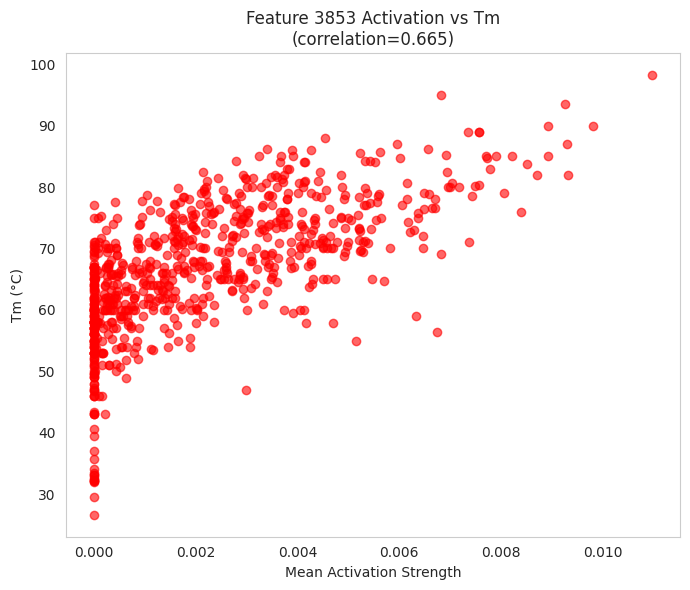

In [26]:
# Correlation analysis with Tm values
def analyze_tm_correlation():
    """Correlation analysis between feature activation and Tm values"""
    
    # Feature mean activation and Tm values for each protein
    mean_activations = [stats['mean_activation'] for stats in protein_feature_strengths]
    tm_values = [stats['label'] for stats in protein_feature_strengths]
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(mean_activations, tm_values)[0, 1]
    
    print(f"\nCorrelation between Feature {feature_idx} activation and Tm values:")
    print(f"Pearson correlation coefficient: {correlation:.4f}")
    
    # Scatter plot
    fig, ax1 = plt.subplots(figsize=(7, 6))
    
    # Activation vs Tm
    ax1.scatter(mean_activations, tm_values, alpha=0.6, color='red')
    ax1.set_xlabel('Mean Activation Strength')
    ax1.set_ylabel('Tm (°C)')
    ax1.set_title(f'Feature {feature_idx} Activation vs Tm\n(correlation={correlation:.3f})')
    ax1.grid(False)
    
    plt.tight_layout()
    plt.show()

analyze_tm_correlation()


## Correlation analysis activation of largest-weighted and lowest-weighted feature with Tm value

In [27]:
def get_protein_feature_strengths(sparse_before_pooling, df, feature_idx, normalize=False):
    """Function to get activation pattern of specified feature in each protein"""
    
    # Get activation pattern of the feature in each protein
    activations_per_protein = []
    sequence_lengths = []
    
    for i, protein_tensor in enumerate(sparse_before_pooling):
        # protein_tensor shape: [seq_len, 2560]
        feature_activations = protein_tensor[:, feature_idx].numpy()  # [seq_len]
        activations_per_protein.append(feature_activations)
        sequence_lengths.append(len(feature_activations))
    
    # Get information on proteins where feature fires strongly
    protein_feature_strengths = []
    mean_activations = []  # Save for normalization
    
    for i, activations in enumerate(activations_per_protein):
        # Average activation strength of feature in each protein
        mean_activation = np.mean(activations)
        max_activation = np.max(activations)
        
        protein_feature_strengths.append({
            'protein_id': i,
            'mean_activation': mean_activation,
            'max_activation': max_activation,
            'nonzero_positions': np.count_nonzero(activations),
            'sequence_length': len(activations),
            'label': df.iloc[i]['label'],
            'feature_idx': feature_idx
        })
        
        mean_activations.append(mean_activation)
    
    # Execute normalization
    if normalize:
        mean_activations = np.array(mean_activations)
        min_activation = np.min(mean_activations)
        max_activation = np.max(mean_activations)
        
        # Handle case where max and min are the same
        if max_activation == min_activation:
            print(f"Warning: All mean activations are the same ({min_activation}). Normalization skipped.")
        else:
            # Normalize to 0-1
            normalized_activations = (mean_activations - min_activation) / (max_activation - min_activation)
            
            # Update normalized values
            for i, protein_data in enumerate(protein_feature_strengths):
                protein_data['mean_activation'] = normalized_activations[i]
                protein_data['mean_activation_original'] = mean_activations[i]  # Save original value
                protein_data['normalization_info'] = {
                    'min_original': min_activation,
                    'max_original': max_activation
                }
    
    return protein_feature_strengths

In [28]:
# Get feature_idx with largest positive weight and smallest negative weight
posi_feature_idx = np.argmax(sparse_weights)
neg_feature_idx = np.argmin(sparse_weights)

print(f"largest positive weight feature idx: {posi_feature_idx}, weight: {sparse_weights[posi_feature_idx]:.6f}")
print(f"smallest negative weight feature idx: {neg_feature_idx}, weight: {sparse_weights[neg_feature_idx]:.6f}")

posi_protein_feature_strengths_normalized = get_protein_feature_strengths(
    sparse_before_pooling=sparse_before_pooling,
    df=df,
    feature_idx=posi_feature_idx,
    normalize=True
)

neg_protein_feature_strengths_normalized = get_protein_feature_strengths(
    sparse_before_pooling=sparse_before_pooling,
    df=df,
    feature_idx=neg_feature_idx,
    normalize=True
)

largest positive weight feature idx: 3853, weight: 0.191257
smallest negative weight feature idx: 3326, weight: -0.224339



Correlation between positive/negative feature activations and Tm values:
Pearson correlation coefficient (3853): 0.6653
Pearson correlation coefficient (3326): -0.2253
Mean activation range (3853): 0.000000 to 1.000000
Mean activation range (3326): 0.000000 to 1.000000
Mean activation std (3853): 0.197392
Mean activation std (3326): 0.197757


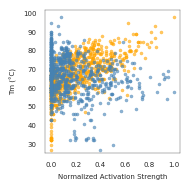

In [30]:
# Correlation analysis with Tm values
def analyze_tm_correlation():
    """Correlation analysis between feature activation and Tm values"""
    
    # Feature mean activation and Tm values for each protein
    posi_normalized_activations = [stats['mean_activation'] for stats in posi_protein_feature_strengths_normalized]
    neg_normalized_activations = [stats['mean_activation'] for stats in neg_protein_feature_strengths_normalized]
    tm_values = [stats['label'] for stats in posi_protein_feature_strengths_normalized]
    
    # Calculate correlation coefficient
    posi_correlation = np.corrcoef(posi_normalized_activations, tm_values)[0, 1]
    neg_correlation = np.corrcoef(neg_normalized_activations, tm_values)[0, 1]
    
    print(f"\nCorrelation between positive/negative feature activations and Tm values:")
    print(f"Pearson correlation coefficient ({posi_feature_idx}): {posi_correlation:.4f}")
    print(f"Pearson correlation coefficient ({neg_feature_idx}): {neg_correlation:.4f}")
    
    # Check data range
    print(f"Mean activation range ({posi_feature_idx}): {min(posi_normalized_activations):.6f} to {max(posi_normalized_activations):.6f}")
    print(f"Mean activation range ({neg_feature_idx}): {min(neg_normalized_activations):.6f} to {max(neg_normalized_activations):.6f}")
    print(f"Mean activation std ({posi_feature_idx}): {np.std(posi_normalized_activations):.6f}")
    print(f"Mean activation std ({neg_feature_idx}): {np.std(neg_normalized_activations):.6f}")
    
    # Scatter plot
    fig, ax = plt.subplots(figsize=(2, 2))
    
    BORDER_COLOR = "0.3"
    line_width = 0.3

    # Activation vs Tm
    ax.scatter(posi_normalized_activations, tm_values, color="orange", s=5, alpha=0.6, linewidth=0.3)
    ax.scatter(neg_normalized_activations, tm_values, color="steelblue", s=5, alpha=0.6, linewidth=0.3)
    ax.set_xlabel('Normalized Activation Strength', fontsize=5)
    ax.set_ylabel('Tm (°C)', fontsize=5)
    
    # Set x-axis tick interval to 0.005
    #x_min = min(mean_activations)
    #x_max = max(mean_activations)
    
    # Set ticks at 0.005 intervals
    #x_ticks = np.arange(np.floor(x_min * 1000 / 5) * 5 / 1000, 
    #                   np.ceil(x_max * 1000 / 5) * 5 / 1000, 0.005)
    #ax.set_xticks(x_ticks)
    
    # Format tick labels (display to 3 decimal places)
    #ax.set_xticklabels([f'{tick:.3f}' for tick in x_ticks])

    ax.set_ylim(25, 102)
    
    # Set tick lines
    ax.tick_params(axis="x", length=3, width=0.5, labelsize=5)
    ax.tick_params(axis="y", length=3, width=0.5, labelsize=5)
    
    # Set grid
    ax.grid(False)

    # Set border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(BORDER_COLOR)
        spine.set_linewidth(line_width)
    
    plt.tight_layout()

    save_dir = 'figure'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    save_path = os.path.join(save_dir, f'sft_feature_{posi_feature_idx}_{neg_feature_idx}_tm_correlation.png')
    plt.savefig(save_path, dpi=350, bbox_inches="tight")
    plt.show()

analyze_tm_correlation()

## Visualization of Firing Positions

### Heatmap after alignment with aho numbering

In [31]:
def build_ungapped_to_aho_map(seq_aho: str):
    """
    Create a map associating ungapped sequence indices with AHO positions
    from a gapped AHO-aligned sequence.
    """
    mapping = []
    for i, ch in enumerate(seq_aho):
        if ch != '-':
            mapping.append(i + 1)  # AHo positions are 1-based
    return mapping

# Prepare single list to store all information
all_protein_data = []

aho_len = 149  # Set according to maximum AHo alignment length
num_proteins = len(protein_feature_strengths)
aho_heatmap_matrix = np.zeros((num_proteins, aho_len))

for i, protein_info in enumerate(protein_feature_strengths):
    # 1. Get common information based on ID (using .loc)
    protein_id = protein_info['protein_id']
    activations = activations_per_protein[protein_id]
    tm_val = df.loc[protein_id]['label']
    aho_gapped_sequence = sequences_df.loc[protein_id]['sequence_aho']
    ungapped_sequence = sequences_df.loc[protein_id]['sequence_aho_ungapped']

    # 2. Calculate AHO alignment and update heatmap matrix
    ungapped_to_aho = build_ungapped_to_aho_map(aho_gapped_sequence)
    L = min(len(activations), len(ungapped_to_aho))
    
    for u_idx in range(L):
        aho_pos = ungapped_to_aho[u_idx] - 1
        if aho_pos < aho_len:
            aho_heatmap_matrix[i, aho_pos] = activations[u_idx]
    
    # 3. Combine all information into one dictionary and add to list
    all_protein_data.append({
        'id': protein_id,
        'tm': tm_val,
        'label': f"ID{protein_id} (Tm={tm_val:.1f}C)",
        # Information corresponding to original 'protein_data'
        'activations': activations,
        'ungapped_sequence': ungapped_sequence,
        # Information corresponding to original 'protein_data_aho_aligned'
        'aho_aligned_activations': aho_heatmap_matrix[i].copy(), # .copy() to store value not reference
        'aho_mean_activation': np.mean(activations),
        'aho_gapped_sequence': aho_gapped_sequence,
    })

all_protein_data.sort(key=lambda x: x['tm'], reverse=True)

print(f"number of proteins: {len(all_protein_data)}")
print(f"alignment heatmap matrix shape: {aho_heatmap_matrix.shape}")

number of proteins: 764
alignment heatmap matrix shape: (764, 149)


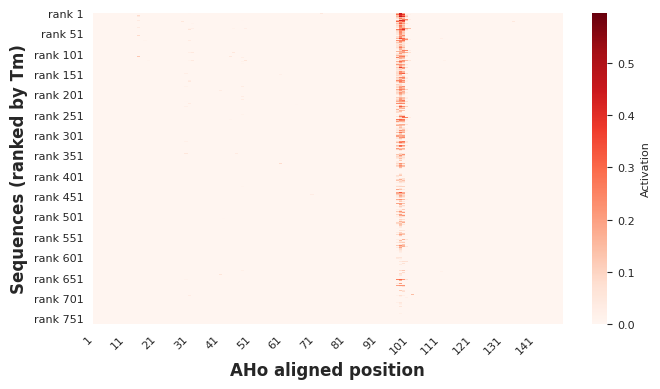

In [32]:
activations_list = [protein['aho_aligned_activations'] for protein in all_protein_data]
protein_ids = [protein['id'] for protein in all_protein_data]

df_heatmap = pd.DataFrame(
    activations_list,
    columns=[f"AHo{j+1}" for j in range(aho_len)],
    index=protein_ids)

fig, ax = plt.subplots(figsize=(7, 4))

cbar = sns.heatmap(
    df_heatmap,
    ax = ax,
    cmap="Reds",
    cbar_kws={'label': 'Activation'},
    yticklabels=False,
    xticklabels=False
)

cbar.figure.axes[-1].tick_params(labelsize=8)
cbar.figure.axes[-1].set_ylabel('Activation', fontsize=8)

ax.set_xlabel("AHo aligned position", fontsize=12, fontweight='bold')
ax.set_ylabel("Sequences (ranked by Tm)", fontsize=12, fontweight='bold')

x_ticks = list(range(0, aho_len, 10))
x_labels = [f"{i+1}" for i in x_ticks]
ax.set_xticks([x + 0.5 for x in x_ticks])
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)

y_ticks = list(range(0, len(all_protein_data), 50))
y_labels = [f"rank {i+1}" for i in y_ticks]
ax.set_yticks([y + 0.5 for y in y_ticks])
ax.set_yticklabels(y_labels, fontsize=8)

plt.tight_layout()

save_dir = 'figure'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'aho_heatmap_all_{feature_idx}.png')
plt.savefig(save_path, dpi=350, bbox_inches="tight")
plt.show()

## create activation score sheet for structre mapping

### Mapping to high Tm VHH

In [27]:
high_tm_sequence = "QLQLVESGGGLVQAGGSLRLSCAASGRTFSSATMGWFRQAPGKEREFVAAISWSGLSRYYADSVKGRFTISRDNAENTVYLQMNSLKTEDTAVYYCAADSWGCSGLGCYDARQYDVWGQGTQVTVSS"

# search sequence in all_protein_data and get the information
high_tm_sequence_data = [protein for protein in all_protein_data if protein['ungapped_sequence'] == high_tm_sequence]

print(f"Tm_high vhh id:{high_tm_sequence_data[0]['id']}")
print(f"Tm_high vhh:{high_tm_sequence_data[0]['tm']}")

if len(high_tm_sequence_data) == 0:
    raise ValueError("high_tm_sequence data is not found.")

target = high_tm_sequence_data[0]
protein_id = target["id"]
seq = target["ungapped_sequence"]
acts = np.asarray(target["activations"], dtype=float)

if len(seq) != len(acts):
    raise ValueError(f"sequence length ({len(seq)}) and activations length ({len(acts)}) do not match.")

# normalize by positive values
acts_pos = np.clip(acts, a_min=0.0, a_max=None)
max_pos = acts_pos.max() if acts_pos.size > 0 else 0.0
if max_pos > 0:
    scores = acts_pos / max_pos
else:
    scores = np.zeros_like(acts_pos)

# create DataFrame (only necessary columns) 
df_scores = pd.DataFrame({
    "resi": np.arange(1, len(seq) + 1, dtype=int),  
    "aa": list(seq),
    "score": scores.astype(float),
    "raw_activation": acts.astype(float),
})

# keep only score > 0
df_scores = df_scores[df_scores["score"] > 0].reset_index(drop=True)

out_dir = "./score_tables"
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, f"scores_SFT_feature{feature_idx}_seqid{protein_id}.csv")
df_scores.to_csv(out_csv, index=False)

print(f"score table is saved: {out_csv}")
print(df_scores.head().to_string(index=False))

Tm_high vhh id:23
Tm_high vhh:98.23
score table is saved: ./score_tables/scores_SFT_feature6699_seqid23.csv
 resi aa    score  raw_activation
   12  V 0.198573        0.018062
   18  L 1.000000        0.090958
   19  R 0.662629        0.060271
   37  F 0.052956        0.004817
   45  R 0.315200        0.028670


### Mapping to the low Tm VHH

In [28]:
low_tm_sequence = "DVQLQASGGGLVQAGGSLRLSCAVSDNTTSLNGMGYYRGPPGKQREFVAYARNNGAPKYADSVMGRFTISYDNSKATVYLQMNNLGPEDTALYYCYAPDRWHTYWAGGTQVTVSS"

# search sequence in all_protein_data and get the information
low_tm_sequence_data = [protein for protein in all_protein_data if protein['ungapped_sequence'] == low_tm_sequence]

print(f"Tm_low vhh id:{low_tm_sequence_data[0]['id']}")
print(f"Tm_low vhh:{low_tm_sequence_data[0]['tm']}")

if len(low_tm_sequence_data) == 0:
    raise ValueError("low_tm_sequence data is not found.")

target = low_tm_sequence_data[0]
protein_id = target["id"]
seq = target["ungapped_sequence"]
acts = np.asarray(target["activations"], dtype=float)

if len(seq) != len(acts):
    raise ValueError(f"sequence length ({len(seq)}) and activations length ({len(acts)}) do not match.")

# normalize by positive values
acts_pos = np.clip(acts, a_min=0.0, a_max=None)
max_pos = acts_pos.max() if acts_pos.size > 0 else 0.0
if max_pos > 0:
    scores = acts_pos / max_pos
else:
    scores = np.zeros_like(acts_pos)

# create DataFrame (only necessary columns) 
df_scores = pd.DataFrame({
    "resi": np.arange(1, len(seq) + 1, dtype=int),  # 1始まり残基番号
    "aa": list(seq),
    "score": scores.astype(float),
    "raw_activation": acts.astype(float),
})

# keep only score > 0
df_scores = df_scores[df_scores["score"] > 0].reset_index(drop=True)

out_dir = "./score_tables"
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, f"scores_SFT_feature{feature_idx}_seqid{protein_id}.csv")
df_scores.to_csv(out_csv, index=False)

print(f"score table is saved: {out_csv}")
print(df_scores.head().to_string(index=False))

Tm_low vhh id:213
Tm_low vhh:43.0
score table is saved: ./score_tables/scores_SFT_feature6699_seqid213.csv
Empty DataFrame
Columns: [resi, aa, score, raw_activation]
Index: []
